In [1]:
from sklearn import datasets
import google.genai as genai
import os
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import numpy as np
import matplotlib.pyplot as plt
import base64
import openml

import requests

from sklearn.datasets import fetch_openml

OPENML_LIST_URL = "https://www.openml.org/api/v1/json/data/list"
rng = np.random.default_rng(15)

from dotenv import load_dotenv
load_dotenv()




False

In [2]:
def openml_list_uci(limit=10000, offset=0, status="active"):
    """
    Returns a list of dataset metadata dicts from OpenML, filtered by tag=uci.
    (Uses the OpenML REST API JSON endpoint.)
    """
    params = {
        "tag": "uci",
        "limit": limit,
        "offset": offset,
        "status": status,
    }
    url = OPENML_LIST_URL + "?" + urlencode(params)
    with urlopen(url) as resp:
        payload = json.load(resp)
        
    datasets = payload.get("data", {}).get("dataset", [])
    return datasets

def quality_to_dict(d):
    """
    Convert OpenML 'quality' list into a dict:
    """
    q = d.get("quality", [])
    if isinstance(q, list):
        return {item.get("name"): item.get("value") for item in q if isinstance(item, dict)}
    return {}

def pick_random_dataset_id(datasets, rng,
                           min_instances=200, max_features=2000):
    """
    Pick a dataset at random.
    Returns a random dataset id from the given datasets.
    """

    filtered = []
    for d in datasets:
        try:
            did = int(d["did"])  # <-- top-level
            q = quality_to_dict(d)

            n = int(float(q.get("NumberOfInstances", 0)))
            p = int(float(q.get("NumberOfFeatures", 0)))

        except Exception:
            continue

        if n >= min_instances and 1 <= p <= max_features:
            filtered.append(did)

    if not filtered:
        raise RuntimeError("No datasets passed the filters. Relax constraints.")

    return int(rng.choice(filtered))

In [3]:
datasets_meta = openml_list_uci(limit=10000, offset=0)

In [4]:
def get_random_ds(d_meta):

    while True:
        data_id = pick_random_dataset_id(d_meta, rng=rng)
        try:
            ds = fetch_openml(data_id=data_id, as_frame=True)
            break
        except Exception as e:
            print("retrying fetch...", e)
            continue

    data = ds.data

    return data_id, data

In [ ]:
RESPONSE_JSON = {
    "graph": "type of graph you want to generate",
    "features": "array of names of features you need to use",
    "title":  "graph title",
    "description": "describe the graph you made in great detail",
    "instruction": "extremely detailed instructions on how to make this draph for the person making it"
}

def get_instructions(client, data, prev_graphs=[]):

    response_instructions = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=f"""You are an analyst that is looking to extract data from a dataset.
            You will be given data, and you must provide a response with the type of graph you want to generate. 
            Be creative you can choose from every different possible visualizations even very unusual ones.
            Don't create charts that will take very long to execute code on, the datasets can be fairly large.
            When creating instructions be mindful that the graph creator can only use matplotlib, numpy, pandas and standard python libraries.
            Also consider that the graphs must be readable and provide meaningful insights about the data.
            Avoid generating these graphs {prev_graphs}, as they were already generated in previous runs
            The response should be exacly in the following JSON format (return nothing else): {json.dumps(RESPONSE_JSON)} \n
            DATA:\n{data}
            """
    )

    templates = plt.style.available

    random_style = rng.choice(templates)
    random_style

    instructions = json.loads(response_instructions.text.removeprefix("```json").removesuffix("```").strip())
    instructions["style"] = str(random_style)

    return instructions


In [6]:
def get_code(client, instructions, data, im_path):

    response_code = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=f"""You are an analyst that is writing code to generate graphs. 
            You will be given a dataset, the features you need to use, the deescription of the graph and the instructions.
            You need to return fully functioning python code that generates that graph. 
            for plotting only use matplotlib (NOT seaborn or plotly). Always use the matplotlib style provided in the insturctions
            Make sure to import all the libraries you use and make sure the code is runnable by with python command exec
            Use 'data' as the variable which contains the dataset. You don't have to make it on your own it will already be in the environment when the code is run.
            Save image to '{im_path}'
            INSTRUCTIONS:\n{instructions}\n
            DATA:\n{data}
            """
    )

    return response_code.text.removeprefix("```python").removesuffix("```").strip()

In [7]:
def get_questions(client, instructions, im_path):
    
    with open(im_path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")

    response_questions = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=[
            {
                "role": "user",
                "parts": [
                    {"text": f"""
                        Generate 10 questions and answers for the graph you are given, generate ONLY questions that you can definitevly answer 
                        \n(DO not replace answers with instructions on how to answer, but give the factual answer.)
                        \nGive questions and answers in an array of JSON objects with keys 'question' and 'answer'.
                        \nQuestions can be about data on the graph or the graph itself (what type, what color represents something, what is on the x axis, etc.)
                        \nThese are the instructions that were given for a specific graph. Along with them is the image of the graph.
                        \nGRAPH GENERATION INSTRUCTION: {instructions}
                    """},
                    {
                        "inline_data": {
                            "mime_type": "image/jpeg",
                            "data": img_b64,
                        }
                    },
                ],
            }
        ],
    )

    questions = json.loads(response_questions.text.removeprefix("```json").removesuffix("```").strip())

    return questions

In [ ]:
def save_data(file, instructions, questions, image_path, dataset_id):
    entry = {
        "path": image_path,
        "type": instructions["graph"],
        "title": instructions["title"],
        "ucmi_dataset_id": dataset_id,
        "used_features": instructions["features"],
        "description": instructions["description"],
        "instruction": instructions["instruction"],
        "style": instructions["style"],
        "questions": questions,
    }

    print(json.dumps(entry, indent=2))

    file.write(json.dumps(entry) + "\n")
    file.flush()

Generating from 19 to 20
GENERATING IMAGE 19:
retrying fetch... Sparse ARFF datasets cannot be loaded with as_frame=True. Use as_frame=False or as_frame='auto' instead.
Getting instructions...
Generating code...
Generating questions...
{
  "path": "dataset\\images\\19.png",
  "type": "Heatmap of Average Hourly Volatility across the Week",
  "title": "Intraday Market Volatility Profile: Hour of Day vs Day of Week",
  "ucmi_dataset_id": 41820,
  "used_features": "Heatmap of Average Hourly Volatility across the Week",
  "description": "This heatmap visualizes market volatility, calculated as the difference between the hourly High and Low bid prices, averaged over the entire 2012-2018 dataset. The vertical axis represents the hour of the day (UTC), and the horizontal axis represents the day of the week. This visualization reveals the 'signature' of the market, highlighting periods of high liquidity and price movement (like the London/New York session overlaps) versus the quiet periods of t

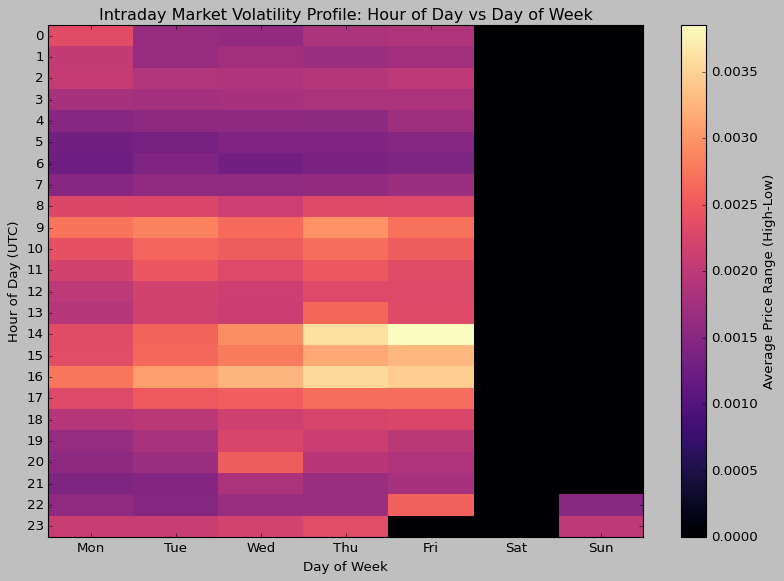

In [ ]:
DATASET_FOLDER = "dataset"
IMAGES_FOLDER = os.path.join(DATASET_FOLDER, "images")
GENERATE_IMAGES = 1

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

f = open(os.path.join(DATASET_FOLDER, "metadata.jsonl"), "a", encoding="utf-8")

n_files = sum(
    1 for f in os.listdir(IMAGES_FOLDER)
    if os.path.isfile(os.path.join(IMAGES_FOLDER, f))
)

print(f"Generating from {n_files} to {n_files + GENERATE_IMAGES}")

prev_graphs = []

for i in range(n_files, n_files + GENERATE_IMAGES):
    print(f"GENERATING IMAGE {i}:")
    ds_id, data = get_random_ds(datasets_meta)

    image_path = os.path.join(IMAGES_FOLDER, f"{i}.png")

    print("Getting instructions...")

    inst = get_instructions(client, data, prev_graphs=prev_graphs)

    prev_graphs.append(inst["graph"])
    if len(prev_graphs) > 10:
        prev_graphs.pop(0)

    print("Generating code...")

    retry = 0
    while retry < 3:
        code = get_code(client, inst, data, im_path=image_path)

        try:
            exec(code)
            break
        except:
            print("retrying code generation")
            retry += 1
    
    if retry == 3:
        continue 

    print("Generating questions...")
    
    quest = get_questions(client, inst, im_path=image_path)

    save_data(file=f, instructions=inst, questions=quest, image_path=image_path, dataset_id=ds_id)

f.close()
    

In [10]:
f.close()